# Feature Engineering for Clustering

In [2]:
import sys
from pathlib import Path

# Add project root to path to allow imports from src
project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

import duckdb
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from src.clustering import db as dbmod
from src.clustering.extract import (
    fetch_city_entities,
    fetch_long_city_measurements,
    fetch_long_country_measurements_for_cities,
    fetch_long_who_air_quality,
    WHO_INDICATOR_CODES_DEFAULT,
)

# Setup plotting
sns.set_theme(style="whitegrid")

## Get Data

In [3]:
db_path = dbmod.default_data_full_db_path()
con = dbmod.connect(db_path)

# Config
YEAR_MIN = 2015
YEAR_MAX = 2023

In [4]:
# Fetch raw long-form data
df_long = fetch_long_city_measurements(con, year_min=YEAR_MIN, year_max=YEAR_MAX)
print(f"Rows: {len(df_long)}")
df_long.head()

Rows: 33275


,geo_code,year,indicator_code,value,flag
0,BE001C,2015,URB_CPOPCB_DE2009V,538100.0,None
1,BE001C,2016,URB_CPOPCB_DE2009V,541954.0,None
2,BE001C,2017,URB_CPOPCB_DE2009V,539814.0,None
3,BE001C,2018,URB_CPOPCB_DE2009V,546413.0,None
4,BE001C,2019,URB_CPOPCB_DE2009V,556367.0,None


In [5]:
# Fetch country-level long-form data (already joined to cities)
# NOTE: Excludes URB and WHO domains by default since those are city-specific indicators.
# Only fetches truly country-level indicators (HLTH, SDG, TRNG, ISOC, etc.)
df_country_long = fetch_long_country_measurements_for_cities(con, year_min=YEAR_MIN, year_max=YEAR_MAX)
print(f"Country Rows: {len(df_country_long)}")
print(f"Unique indicators: {df_country_long['indicator_code'].nunique()}")
print(f"Indicator prefixes: {df_country_long['indicator_code'].str.split('_').str[0].unique().tolist()}")
df_country_long.head(20)

Country Rows: 25973
Unique indicators: 5
Indicator prefixes: ['HLTH', 'ISOC', 'SDG', 'TRNG']


,city_geo_code,year,indicator_code,value
0,BE015C,2015,HLTH_RS_BDS1_HBEDT_TOTAL,573.99
1,BE015C,2016,HLTH_RS_BDS1_HBEDT_TOTAL,570.15
2,BE015C,2017,HLTH_RS_BDS1_HBEDT_TOTAL,562.38
3,BE015C,2018,HLTH_RS_BDS1_HBEDT_TOTAL,560.85
4,BE015C,2019,HLTH_RS_BDS1_HBEDT_TOTAL,556.72
5,BE015C,2020,HLTH_RS_BDS1_HBEDT_TOTAL,553.33
6,BE015C,2021,HLTH_RS_BDS1_HBEDT_TOTAL,549.22
7,BE015C,2022,HLTH_RS_BDS1_HBEDT_TOTAL,544.27
8,BE015C,2023,HLTH_RS_BDS1_HBEDT_TOTAL,539.11
9,BG018C,2015,HLTH_RS_BDS1_HBEDT_TOTAL,779.29


In [6]:
# Fetch city metadata (names and country codes)
cities_df = fetch_city_entities(con)
print(f"Cities: {len(cities_df)}")
cities_df.head()
cities_df.tail()



Cities: 958


,geo_code,geo_name,country_code
953,UK131C,Corby,UK
954,UK132C,Kettering,UK
955,UK133C,Inverclyde (Greenock),UK
956,UK134C,Renfrewshire (Paisley),UK
957,UK135C,Derry & Strabane Local Government District,UK


In [7]:
# Join city names to the long-form data
df_long = df_long.merge(cities_df, on="geo_code", how="left")
df_long.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33275 entries, 0 to 33274
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   geo_code        33275 non-null  object 
 1   year            33275 non-null  int32  
 2   indicator_code  33275 non-null  object 
 3   value           33275 non-null  float64
 4   flag            8154 non-null   object 
 5   geo_name        33275 non-null  object 
 6   country_code    33275 non-null  object 
dtypes: float64(1), int32(1), object(5)
memory usage: 1.7+ MB


In [8]:
# Find the city codes matching the population criteria
city_codes_to_keep = df_long[
    df_long["indicator_code"].str.contains("URB_CPOP1_DE1001V", na=False) & (df_long["value"] >= 500000)
]["geo_code"].unique()

mask = ~np.isin(city_codes_to_keep, ["UK001C", "FR001C"])
city_codes_to_keep = city_codes_to_keep[mask]

# Filter the main dataframe to keep all rows for those cities (all indicators)
df_long_filtered = df_long[df_long["geo_code"].isin(city_codes_to_keep)]

In [9]:

city_codes_to_keep

array(['BE001C', 'BE002C', 'BG001C', 'CH002C', 'CZ001C', 'DE001C',
       'DE002C', 'DE003C', 'DE004C', 'DE005C', 'DE006C', 'DE007C',
       'DE008C', 'DE009C', 'DE010C', 'DE011C', 'DE012C', 'DE013C',
       'DE014C', 'DE080C', 'ES001C', 'ES002C', 'ES003C', 'ES004C',
       'ES005C', 'ES006C', 'ES019C', 'FI001C', 'FR002C', 'FR003C',
       'FR004C', 'FR005C', 'FR006C', 'FR007C', 'HR001C', 'HU001C',
       'IE001C', 'IT001C', 'IT002C', 'IT003C', 'IT004C', 'IT005C',
       'IT006C', 'LT001C', 'LV001C', 'NL001C', 'NL017C', 'NL037C',
       'NO001C', 'PL001C', 'PL002C', 'PL003C', 'PL004C', 'PL005C',
       'PT001C', 'PT002C', 'RO001C', 'SE001C', 'SE002C', 'UK002C',
       'UK003C', 'UK004C', 'UK005C', 'UK007C', 'UK008C', 'UK010C'],
      dtype=object)

In [10]:
df_long_filtered


,geo_code,year,indicator_code,value,flag,geo_name,country_code
0,BE001C,2015,URB_CPOPCB_DE2009V,538100.00,None,Bruxelles/Brussel (greater city),BE
1,BE001C,2016,URB_CPOPCB_DE2009V,541954.00,None,Bruxelles/Brussel (greater city),BE
2,BE001C,2017,URB_CPOPCB_DE2009V,539814.00,None,Bruxelles/Brussel (greater city),BE
3,BE001C,2018,URB_CPOPCB_DE2009V,546413.00,None,Bruxelles/Brussel (greater city),BE
4,BE001C,2019,URB_CPOPCB_DE2009V,556367.00,None,Bruxelles/Brussel (greater city),BE
...,...,...,...,...,...,...,...
31869,UK008C,2018,URB_CTRAN_TT1057I,258.06,None,Manchester,UK
31874,UK010C,2015,URB_CTRAN_TT1057I,343.32,b,Sheffield,UK
31875,UK010C,2016,URB_CTRAN_TT1057I,345.81,None,Sheffield,UK
31876,UK010C,2017,URB_CTRAN_TT1057I,348.05,b,Sheffield,UK


In [11]:
# (Optional debug cell)
geo_counts = df_long_filtered.groupby("geo_name").size().reset_index(name="count")
geo_counts

,geo_name,count
0,'s-Gravenhage (greater city),36
1,Amsterdam (greater city),35
2,Antwerpen (greater city),55
3,Barcelona (greater city),52
4,Berlin,49
...,...,...
61,Wrocław,21
62,Zagreb,53
63,Zaragoza,60
64,Zurich (greater city),51


## Feature Selection & Engineering

In [12]:
# Example: Select a few indicators and take the mean over the years
# Check available indicators
top_indicators = df_long_filtered['indicator_code'].value_counts()
print("Top available indicators:")
print(top_indicators)

Top available indicators:
indicator_code
URB_CPOP1_DE1001V     498
URB_CLMA_EC1010V      432
URB_CEDUC_TE1026V     425
URB_CTRAN_TT1057I     408
URB_CLMA_EC1177V      395
URB_CPOPCB_DE2009V    357
URB_CTOUR_CR2001V     293
Name: count, dtype: int64


In [13]:
# Pivot to wide format (Mean over years)
features_df = df_long_filtered.groupby(["geo_code", "indicator_code"])["value"].mean().round(2).unstack()

# Filter columns with enough data (e.g. > 70% non-null)
thresh = len(features_df) * 0.7
features_df = features_df.dropna(axis=1, thresh=thresh)

# Fill remaining NaNs (optional, pipeline can also do this)
# features_df = features_df.fillna(features_df.median())

features_df = features_df.reset_index()
print(f"Feature Matrix Shape: {features_df.shape}")
features_df.head()

Feature Matrix Shape: (66, 8)


indicator_code,geo_code,URB_CEDUC_TE1026V,URB_CLMA_EC1010V,URB_CLMA_EC1177V,URB_CPOP1_DE1001V,URB_CPOPCB_DE2009V,URB_CTOUR_CR2001V,URB_CTRAN_TT1057I
0,BE001C,113475.00,73210.33,432104.25,1216595.78,560028.56,5352963.80,406.52
1,BE002C,51752.12,19225.78,202655.75,526470.11,161935.44,1587224.33,385.25
2,BG001C,103063.25,19818.88,550648.75,1232743.50,44669.62,1657351.67,NaN
3,CH002C,76006.77,20511.59,353105.74,679716.12,280299.62,3735062.14,427.29
4,CZ001C,129040.33,9435.00,676706.00,1288088.88,NaN,NaN,NaN


In [14]:
# Pivot country data (only contains HLTH, SDG, TRNG, ISOC - no URB/WHO)
country_wide = df_country_long.groupby(["city_geo_code", "indicator_code"])["value"].mean().round(2).unstack()

# Rename columns to distinguish from city indicators
country_wide.columns = [f"COUNTRY_{col}" for col in country_wide.columns]

print(f"Country-level features: {list(country_wide.columns)}")

# Join to city features
features_df = features_df.merge(country_wide, left_on="geo_code", right_index=True, how="left")

print(f"Feature Matrix Shape (with Country Data): {features_df.shape}")
features_df.head()

Country-level features: ['COUNTRY_HLTH_RS_BDS1_HBEDT_TOTAL', 'COUNTRY_ISOC_CIEGI_AC_I_IUGOV12_IND_TOTAL', 'COUNTRY_SDG_11_60', 'COUNTRY_SDG_17_60_VHCN_FX_TOTAL', 'COUNTRY_TRNG_LFSE_01_T_Y25-74']
Feature Matrix Shape (with Country Data): (66, 13)


,geo_code,URB_CEDUC_TE1026V,URB_CLMA_EC1010V,URB_CLMA_EC1177V,URB_CPOP1_DE1001V,URB_CPOPCB_DE2009V,URB_CTOUR_CR2001V,URB_CTRAN_TT1057I,COUNTRY_HLTH_RS_BDS1_HBEDT_TOTAL,COUNTRY_ISOC_CIEGI_AC_I_IUGOV12_IND_TOTAL,COUNTRY_SDG_11_60,COUNTRY_SDG_17_60_VHCN_FX_TOTAL,COUNTRY_TRNG_LFSE_01_T_Y25-74
0,BE001C,113475.00,73210.33,432104.25,1216595.78,560028.56,5352963.80,406.52,556.67,65.26,54.16,74.48,7.60
1,BE002C,51752.12,19225.78,202655.75,526470.11,161935.44,1587224.33,385.25,556.67,65.26,54.16,74.48,7.60
2,BG001C,103063.25,19818.88,550648.75,1232743.50,44669.62,1657351.67,NaN,815.32,26.77,29.62,79.20,1.54
3,CH002C,76006.77,20511.59,353105.74,679716.12,280299.62,3735062.14,427.29,452.09,83.17,52.50,85.60,25.90
4,CZ001C,129040.33,9435.00,676706.00,1288088.88,NaN,NaN,NaN,660.43,62.50,36.62,43.76,7.33


In [15]:
# =============================================================================
# WHO Air Quality Data Integration
# =============================================================================
# This cell:
# 1. Fetches WHO air quality data (PM10, PM2.5, NO2)
# 2. Maps WHO station names to Eurostat city codes using:
#    - Automatic matching via normalized city names
#    - Manual overrides for cities that don't match automatically
# 3. Merges WHO features into features_df
# =============================================================================

import re
import unicodedata

# --- 1. Fetch WHO Data ---
who_long = fetch_long_who_air_quality(con, year_min=YEAR_MIN, year_max=YEAR_MAX)
print(f"WHO Raw Rows: {len(who_long)}")

# Get unique WHO cities
who_unique = who_long[["who_geo_code", "who_geo_name"]].drop_duplicates().copy()

# --- 2. Create Mapping: WHO stations -> Eurostat city codes ---

def normalize_city_name(name):
    """Normalize city name for matching: remove parentheses, country suffix, diacritics."""
    if not isinstance(name, str): 
        return ""
    name = re.sub(r"\(.*?\)", "", name)  # Remove parentheses
    name = name.split("/")[0]  # Remove country suffix like "/FRA"
    name = unicodedata.normalize('NFKD', name).encode('ascii', 'ignore').decode('utf-8')
    return re.sub(r"[^a-z]", "", name.lower().strip())

# Normalize both datasets
cities_df["norm_name"] = cities_df["geo_name"].apply(normalize_city_name)
who_unique["norm_name"] = who_unique["who_geo_name"].apply(normalize_city_name)

# Automatic mapping via normalized names
mapping_auto = cities_df.merge(who_unique, on="norm_name", how="inner")
print(f"Automatic mapping: {len(mapping_auto)} matches")

# --- Manual overrides for problematic cities ---
manual_map = {
    "BE001C": "Brussels/BEL, Belgium",
    "FI001C": "Helsinki Helsingfors/FIN, Finland",
    "NL001C": "Greater Amsterdam/NLD, Netherlands (Kingdom of the)",
    "NL017C": "Gravenhage/NLD, Netherlands (Kingdom of the)",
    "NL037C": "Greater Rotterdam/NLD, Netherlands (Kingdom of the)",
    "PL002C": "Lodz/POL, Poland",
    "PL004C": "Wroclaw/POL, Poland",
    "UK005C": "Bradford/GBR, United Kingdom of Great Britain and Northern Ireland"
}

# Build manual mapping dataframe
manual_df = pd.DataFrame(list(manual_map.items()), columns=["geo_code", "target_who_name"])
manual_matches = manual_df.merge(
    who_unique[["who_geo_code", "who_geo_name"]], 
    left_on="target_who_name", 
    right_on="who_geo_name", 
    how="inner"
)
manual_matches = manual_matches.merge(cities_df[["geo_code", "geo_name"]], on="geo_code", how="left")
print(f"Manual overrides: {len(manual_matches)} matches")

# Combine automatic + manual mappings
mapping_final = pd.concat([
    mapping_auto[["geo_code", "geo_name", "who_geo_code", "who_geo_name"]], 
    manual_matches[["geo_code", "geo_name", "who_geo_code", "who_geo_name"]]
], ignore_index=True).drop_duplicates(subset=["geo_code"], keep="last")

print(f"Total mapping: {len(mapping_final)} Eurostat cities have WHO data")

# --- 3. Pivot WHO data and merge to features_df ---
who_filtered = who_long.merge(mapping_final[["who_geo_code", "geo_code"]], on="who_geo_code", how="inner")
who_wide = who_filtered.groupby(["geo_code", "indicator_code"])["value"].mean().round(2).unstack()

# Merge WHO features into main features_df
features_df = features_df.merge(who_wide, left_on="geo_code", right_index=True, how="left")

# --- 4. Report results ---
who_cols = [c for c in features_df.columns if c.startswith("WHO_")]
print(f"\nWHO features added: {who_cols}")
print(f"Feature Matrix Shape: {features_df.shape}")
print(f"Missing WHO data: {features_df[who_cols].isnull().all(axis=1).sum()} cities have no WHO data")




WHO Raw Rows: 40982
Automatic mapping: 723 matches
Manual overrides: 8 matches
Total mapping: 727 Eurostat cities have WHO data

WHO features added: ['WHO_NO2', 'WHO_PM10', 'WHO_PM25']
Feature Matrix Shape: (66, 16)
Missing WHO data: 0 cities have no WHO data


In [16]:
# (Cell removed - WHO processing is now consolidated in the cell above)

In [17]:
# Search for target cities in the WHO unique list to find the EXACT string
search_terms = ["Brussels", "Helsinki", "Amsterdam", "Gravenhage", "Rotterdam", "Lodz", "Wroclaw", "Bradford"]

print("--- Searching for exact WHO names ---")
for term in search_terms:
    matches = who_unique[who_unique["who_geo_name"].str.contains(term, case=False, na=False)]
    if not matches.empty:
        print(f"\nMatches for '{term}':")
        for idx, row in matches.iterrows():
            print(f"  Code: {row['who_geo_code']} | Name: '{row['who_geo_name']}'")
    else:
        print(f"\nNo match found for '{term}'")

--- Searching for exact WHO names ---

Matches for 'Brussels':
  Code: BEL_Brussels_BEL | Name: 'Brussels/BEL, Belgium'

Matches for 'Helsinki':
  Code: FIN_Helsinki_Helsingfors_FIN | Name: 'Helsinki Helsingfors/FIN, Finland'

Matches for 'Amsterdam':
  Code: NLD_Greater_Amsterdam_NLD | Name: 'Greater Amsterdam/NLD, Netherlands (Kingdom of the)'

Matches for 'Gravenhage':
  Code: NLD_Gravenhage_NLD | Name: 'Gravenhage/NLD, Netherlands (Kingdom of the)'

Matches for 'Rotterdam':
  Code: NLD_Greater_Rotterdam_NLD | Name: 'Greater Rotterdam/NLD, Netherlands (Kingdom of the)'

Matches for 'Lodz':
  Code: POL_Klodzko_POL | Name: 'Klodzko/POL, Poland'
  Code: POL_Lodz_POL | Name: 'Lodz/POL, Poland'

Matches for 'Wroclaw':
  Code: POL_Inowroclaw_POL | Name: 'Inowroclaw/POL, Poland'
  Code: POL_Wroclaw_POL | Name: 'Wroclaw/POL, Poland'

Matches for 'Bradford':
  Code: GBR_Bradford_GBR | Name: 'Bradford/GBR, United Kingdom of Great Britain and Northern Ireland'


In [18]:
# (Optional debug cell) Check which cities are missing WHO data
missing_who = features_df[features_df["WHO_PM10"].isnull()].copy()

# Join with cities_df to get the 'geo_name'
missing_with_names = missing_who.merge(
    cities_df[["geo_code", "geo_name"]], 
    on="geo_code", 
    how="left"
)

print(f"Cities missing WHO data: {len(missing_with_names)}")
missing_with_names[["geo_code", "geo_name"]]

Cities missing WHO data: 1


,geo_code,geo_name
0,UK005C,Bradford


In [19]:
# (Cell removed - WHO merge is now done in the consolidated WHO processing cell above)


## Correlation matrix

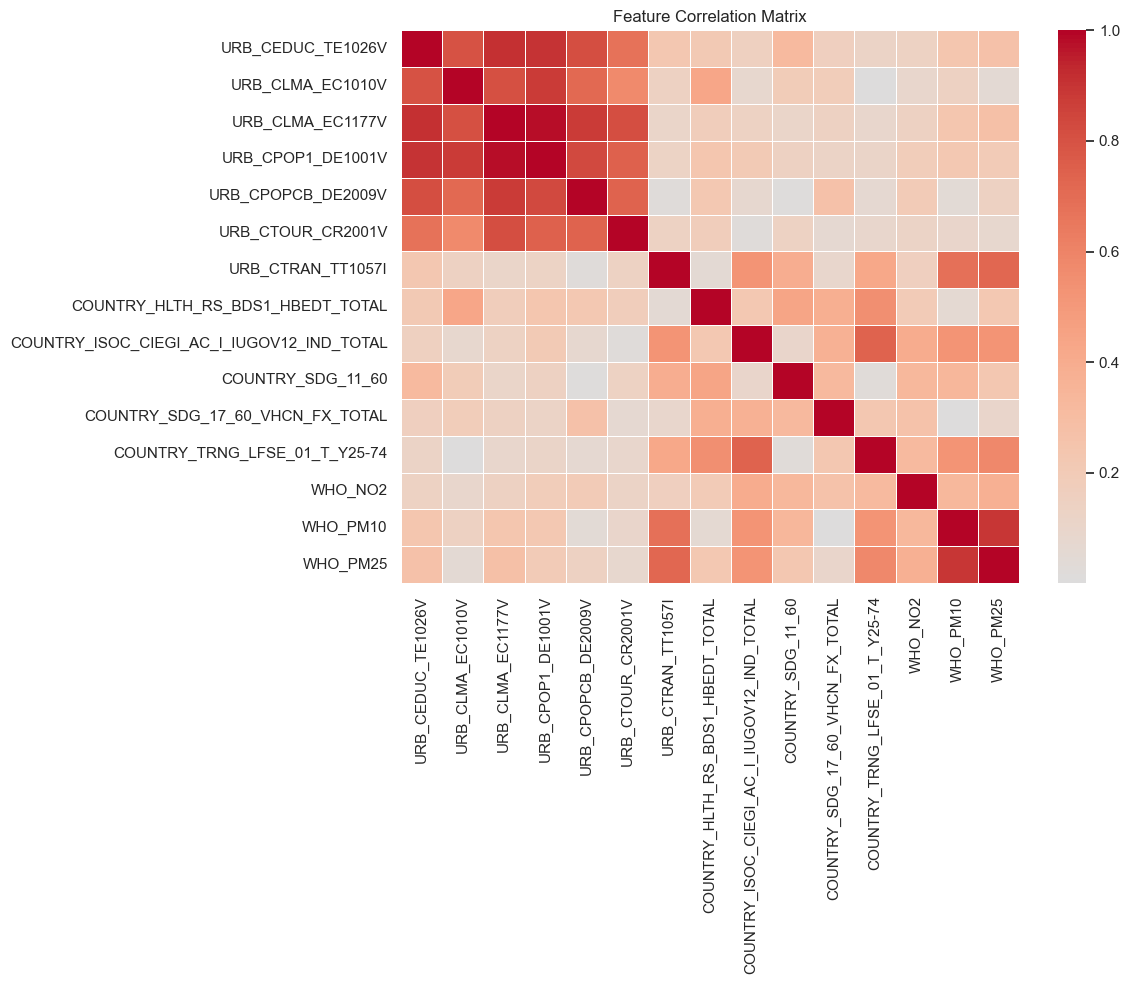

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

corr_matrix = features_df.select_dtypes(include=[np.number]).corr().abs()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=False, cmap="coolwarm", center=0, linewidths=.5)
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()


In [21]:
features_df.head(20)

,geo_code,URB_CEDUC_TE1026V,URB_CLMA_EC1010V,URB_CLMA_EC1177V,URB_CPOP1_DE1001V,URB_CPOPCB_DE2009V,URB_CTOUR_CR2001V,URB_CTRAN_TT1057I,COUNTRY_HLTH_RS_BDS1_HBEDT_TOTAL,COUNTRY_ISOC_CIEGI_AC_I_IUGOV12_IND_TOTAL,COUNTRY_SDG_11_60,COUNTRY_SDG_17_60_VHCN_FX_TOTAL,COUNTRY_TRNG_LFSE_01_T_Y25-74,WHO_NO2,WHO_PM10,WHO_PM25
0,BE001C,113475.00,73210.33,432104.25,1216595.78,560028.56,5352963.80,406.52,556.67,65.26,54.16,74.48,7.60,32.85,19.70,13.21
1,BE002C,51752.12,19225.78,202655.75,526470.11,161935.44,1587224.33,385.25,556.67,65.26,54.16,74.48,7.60,33.48,22.94,13.38
2,BG001C,103063.25,19818.88,550648.75,1232743.50,44669.62,1657351.67,NaN,815.32,26.77,29.62,79.20,1.54,23.75,30.41,14.03
3,CH002C,76006.77,20511.59,353105.74,679716.12,280299.62,3735062.14,427.29,452.09,83.17,52.50,85.60,25.90,29.96,15.44,10.73
4,CZ001C,129040.33,9435.00,676706.00,1288088.88,NaN,NaN,NaN,660.43,62.50,36.62,43.76,7.33,27.52,22.56,15.78
5,DE001C,193197.67,131468.89,1738073.33,3621037.00,NaN,28623731.50,290.16,786.86,58.08,68.31,62.00,6.96,31.45,21.52,14.43
6,DE002C,109280.56,45181.11,916955.56,1830909.78,459614.29,12635750.83,345.14,786.86,58.08,68.31,62.00,6.96,28.48,18.76,12.24
7,DE003C,114089.00,29322.44,780902.33,1471604.44,385760.00,14370249.17,348.02,786.86,58.08,68.31,62.00,6.96,36.69,19.19,11.81
8,DE004C,102329.78,28238.89,515108.11,1075393.67,233228.57,5571186.67,359.11,786.86,58.08,68.31,62.00,6.96,36.84,18.89,12.35
9,DE005C,70128.22,18893.00,368182.22,749604.00,248155.56,8674903.00,319.67,786.86,58.08,68.31,62.00,6.96,34.96,17.78,12.38


In [22]:
# =============================================================================
# Save Final Feature Matrix
# =============================================================================

out_dir = project_root / "output" / "clustering" 
out_dir.mkdir(parents=True, exist_ok=True)
out_path = out_dir / "custom_features_notebook.csv"

# Verify what we're saving
print("=" * 60)
print("FINAL FEATURE MATRIX SUMMARY")
print("=" * 60)
print(f"Shape: {features_df.shape[0]} cities × {features_df.shape[1]} columns")
print(f"\nColumns:")

# Group columns by type
city_cols = [c for c in features_df.columns if c.startswith("URB_")]
country_cols = [c for c in features_df.columns if c.startswith("COUNTRY_")]
who_cols = [c for c in features_df.columns if c.startswith("WHO_")]
other_cols = [c for c in features_df.columns if c not in city_cols + country_cols + who_cols]

print(f"  - ID/other: {other_cols}")
print(f"  - City-level (URB_*): {len(city_cols)} features")
print(f"  - Country-level (COUNTRY_*): {len(country_cols)} features")
print(f"  - WHO air quality (WHO_*): {len(who_cols)} features")

print(f"\nMissing data:")
print(f"  - Cities with all WHO data: {features_df[who_cols].notna().all(axis=1).sum()}")
print(f"  - Cities missing some WHO: {features_df[who_cols].isna().any(axis=1).sum()}")

# Save
features_df.to_csv(out_path, index=False)
print(f"\n✓ Saved to {out_path}")

FINAL FEATURE MATRIX SUMMARY
Shape: 66 cities × 16 columns

Columns:
  - ID/other: ['geo_code']
  - City-level (URB_*): 7 features
  - Country-level (COUNTRY_*): 5 features
  - WHO air quality (WHO_*): 3 features

Missing data:
  - Cities with all WHO data: 65
  - Cities missing some WHO: 1

✓ Saved to /Users/felixwegener/freelancing/data-analytics-project/output/clustering/custom_features_notebook.csv


In [23]:
con.close()